# UTS Kasus 1 Data Tabular (Machine Learning)

Nama : Rio Ramadhani Harllambang

NIM : 1202220205

Kelas : SI-46-EDM

## API Token Kaggle

In [1]:
mkdir -p ~/.kaggle && echo KGAT_77778d82436b57f31950aa6d250920ae > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

## Load Titanic Data
Muat dataset pelatihan dan pengujian Titanic yang telah diunduh oleh `kagglehub` ke dalam DataFrame pandas untuk diproses lebih lanjut.


In [2]:
import pandas as pd
import kagglehub
import os

# Download the Titanic competition files
competition_path = kagglehub.competition_download('titanic')

# Construct the full paths to the training and testing datasets
train_csv_path = os.path.join(competition_path, 'train.csv')
test_csv_path = os.path.join(competition_path, 'test.csv')

# Load the Titanic training dataset
train_df = pd.read_csv(train_csv_path)

# Load the Titanic testing dataset
test_df = pd.read_csv(test_csv_path)

print("Titanic Training DataFrame (train_df):")
print(train_df.head())
print("\nTitanic Testing DataFrame (test_df):")
print(test_df.head())

100%|██████████| 34.1k/34.1k [00:00<00:00, 32.9MB/s]

Extracting files...
Titanic Training DataFrame (train_df):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        

## Initial Data Exploration
Lakukan eksplorasi data awal untuk memahami struktur data, tipe data, distribusi fitur, dan mengidentifikasi nilai yang hilang di seluruh dataset pelatihan dan pengujian.

In [3]:
# Informasi umum tentang dataset pelatihan
print("\n--- Informasi Dataset Pelatihan (train_df) ---")
train_df.info()


--- Informasi Dataset Pelatihan (train_df) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Statistik deskriptif untuk dataset pelatihan
print("\n--- Statistik Deskriptif Dataset Pelatihan (train_df) ---")
display(train_df.describe())


--- Statistik Deskriptif Dataset Pelatihan (train_df) ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Jumlah nilai yang hilang di dataset pelatihan
print("\n--- Nilai Hilang Dataset Pelatihan (train_df) ---")
display(train_df.isnull().sum())


--- Nilai Hilang Dataset Pelatihan (train_df) ---


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
# Informasi umum tentang dataset pengujian
print("\n--- Informasi Dataset Pengujian (test_df) ---")
test_df.info()


--- Informasi Dataset Pengujian (test_df) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [7]:
# Statistik deskriptif untuk dataset pengujian
print("\n--- Statistik Deskriptif Dataset Pengujian (test_df) ---")
display(test_df.describe())


--- Statistik Deskriptif Dataset Pengujian (test_df) ---


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
# Jumlah nilai yang hilang di dataset pengujian
print("\n--- Nilai Hilang Dataset Pengujian (test_df) ---")
display(test_df.isnull().sum())


--- Nilai Hilang Dataset Pengujian (test_df) ---


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


## Deskripsi Dataset dan Tantangan Utama

Setelah melakukan muat data dan eksplorasi awal, berikut adalah deskripsi dataset dan tantangan utama yang diidentifikasi:

*   **Jumlah Data:** Dataset pelatihan (`train_df`) berisi 891 baris data, sedangkan dataset pengujian (`test_df`) berisi 418 baris. Masing-masing memiliki 12 dan 11 kolom.

*   **Distribusi Kelas ('Survived'):** Data pelatihan menunjukkan adanya ketidakseimbangan kelas pada target `Survived`. Jumlah penumpang yang tidak selamat (`0`) lebih banyak dibandingkan yang selamat (`1`). Detail distribusi ini akan lebih jelas terlihat pada visualisasi di bagian EDA.

*   **Karakteristik Fitur dan Nilai Hilang:**
    *   `Age` memiliki banyak nilai hilang pada kedua dataset.
    *   `Cabin` memiliki sangat banyak nilai hilang, menjadikannya kandidat kuat untuk dihapus atau memerlukan strategi imputasi yang kompleks.
    *   `Embarked` memiliki sedikit nilai hilang pada `train_df`.
    *   `Fare` memiliki satu nilai hilang pada `test_df`.
    *   Fitur seperti `Name`, `Sex`, `Ticket`, `Embarked`, dan `Title` (yang akan diekstrak) adalah kategorikal dan perlu diubah menjadi format numerik untuk pemodelan.

*   **Tantangan Utama:**
    1.  **Penanganan Nilai Hilang:** Imputasi yang tepat untuk `Age`, `Embarked`, `Fare`, dan keputusan untuk `Cabin` sangat krusial.
    2.  **Rekayasa Fitur:** Fitur seperti `Name` dan kombinasi `SibSp`/`Parch` menawarkan potensi untuk membuat fitur baru yang lebih informatif (`Title`, `FamilySize`, `IsAlone`).
    3.  **Encoding Fitur Kategorikal:** Mengubah fitur kategorikal menjadi numerik agar dapat diproses oleh algoritma Machine Learning.
    4.  **Ketidakseimbangan Kelas:** Distribusi kelas target `Survived` yang tidak seimbang mungkin perlu ditangani (misalnya dengan oversampling, undersampling, atau penggunaan metrik evaluasi yang tepat) untuk mencegah model bias terhadap kelas mayoritas.

## Eksplorasi Data (EDA) - Visualisasi

Melakukan visualisasi data untuk memahami distribusi kunci dan hubungan antar fitur, khususnya terhadap target 'Survived'.

/tmp/ipykernel_910/3952252226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_df, palette='viridis')


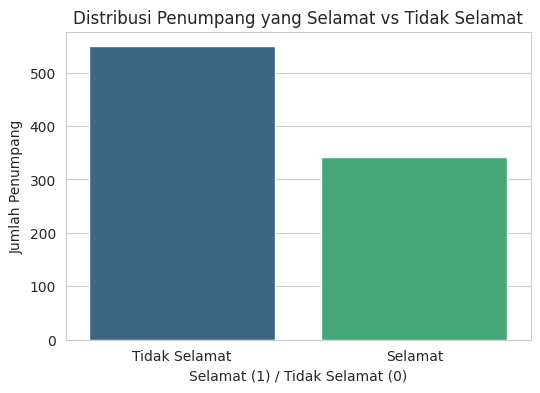

/tmp/ipykernel_910/3952252226.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train_df, palette='mako')


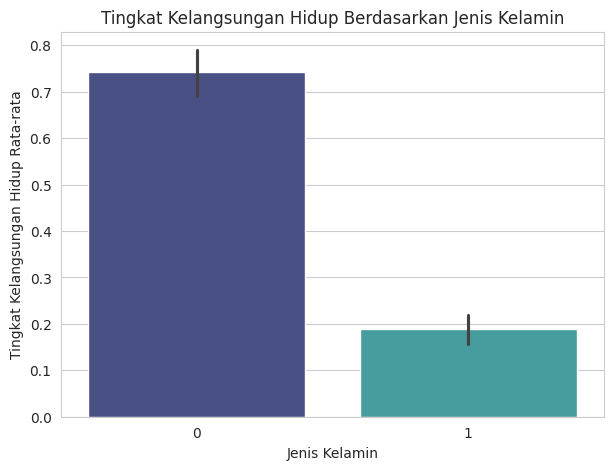

/tmp/ipykernel_910/3952252226.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_df, palette='flare')


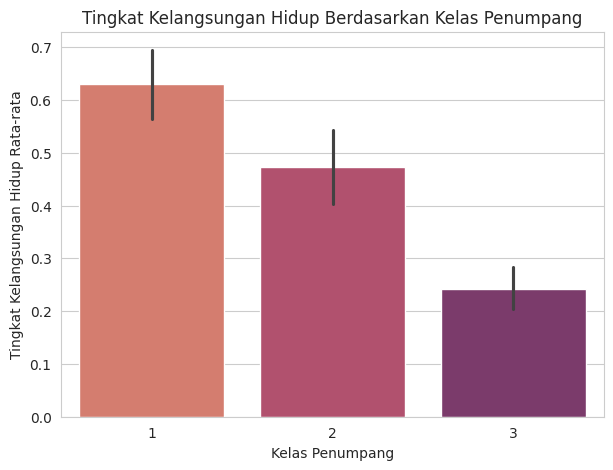

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# 1. Distribusi Kelas Target (Survived)
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train_df, palette='viridis')
plt.title('Distribusi Penumpang yang Selamat vs Tidak Selamat')
plt.xlabel('Selamat (1) / Tidak Selamat (0)')
plt.ylabel('Jumlah Penumpang')
plt.xticks([0, 1], ['Tidak Selamat', 'Selamat'])
plt.show()

# 2. Tingkat Kelangsungan Hidup Berdasarkan Jenis Kelamin
plt.figure(figsize=(7, 5))
sns.barplot(x='Sex', y='Survived', data=train_df, palette='mako')
plt.title('Tingkat Kelangsungan Hidup Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Tingkat Kelangsungan Hidup Rata-rata')
plt.show()

# 3. Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang (Pclass)
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=train_df, palette='flare')
plt.title('Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang')
plt.xlabel('Kelas Penumpang')
plt.ylabel('Tingkat Kelangsungan Hidup Rata-rata')
plt.show()

Dari visualisasi di atas, dapat diamati beberapa hal:

*   **Distribusi Target (Survived)**: Terlihat adanya ketidakseimbangan kelas, di mana jumlah penumpang yang tidak selamat (0) lebih banyak daripada yang selamat (1). Ini perlu diperhatikan saat melatih model.
*   **Tingkat Kelangsungan Hidup Berdasarkan Jenis Kelamin (Sex)**: Wanita memiliki tingkat kelangsungan hidup yang jauh lebih tinggi dibandingkan pria. Ini adalah salah satu prediktor terkuat dalam dataset Titanic.
*   **Tingkat Kelangsungan Hidup Berdasarkan Kelas Penumpang (Pclass)**: Penumpang di kelas 1 memiliki tingkat kelangsungan hidup tertinggi, diikuti oleh kelas 2, dan terakhir kelas 3. Hal ini menunjukkan adanya korelasi kuat antara status sosial/ekonomi dengan peluang bertahan hidup.

## Feature Engineering - Title Extraction
Ekstrak gelar (misalnya, Mr., Mrs., Miss, Master) dari kolom 'Name' dan kelompokkan gelar yang kurang umum untuk membuat fitur 'Title' baru.

In [12]:
for df in [train_df, test_df]:
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles for both datasets
for df in [train_df, test_df]:
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona', 'Mlle', 'Ms', 'Mme'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("Distribusi Title di dataset pelatihan:")
display(train_df['Title'].value_counts())

print("\nDistribusi Title di dataset pengujian:")
display(test_df['Title'].value_counts())

Distribusi Title di dataset pelatihan:


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_910/2309010125.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27



Distribusi Title di dataset pengujian:


,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Rare,7


## Feature Engineering - Age Binning and Imputation

Buat kelompok usia (`AgeBand`) dan isi nilai `Age` yang hilang menggunakan median usia berdasarkan `Title` untuk menjaga konsistensi dalam data.

In [13]:
# Isi nilai 'Age' yang hilang dengan median 'Age' untuk setiap 'Title'
for df in [train_df, test_df]:
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Buat kelompok usia (AgeBand)
for df in [train_df, test_df]:
    df.loc[df['Age'] <= 16, 'Age'] = 0
    df.loc[(df['Age'] > 16) & (df['Age'] <= 32), 'Age'] = 1
    df.loc[(df['Age'] > 32) & (df['Age'] <= 48), 'Age'] = 2
    df.loc[(df['Age'] > 48) & (df['Age'] <= 64), 'Age'] = 3
    df.loc[df['Age'] > 64, 'Age'] = 4

    # Konversi 'Age' ke tipe integer
    df['Age'] = df['Age'].astype(int)

print("Distribusi Age setelah binning dan imputasi di dataset pelatihan:")
display(train_df[['Title', 'Age']].head())
display(train_df['Age'].value_counts())

print("\nNilai hilang di kolom Age setelah imputasi (train_df):")
display(train_df['Age'].isnull().sum())

print("\nDistribusi Age setelah binning dan imputasi di dataset pengujian:")
display(test_df[['Title', 'Age']].head())
display(test_df['Age'].value_counts())

print("\nNilai hilang di kolom Age setelah imputasi (test_df):")
display(test_df['Age'].isnull().sum())

Distribusi Age setelah binning dan imputasi di dataset pelatihan:


,Title,Age
0,Mr,1
1,Mrs,2
2,Miss,1
3,Mrs,2
4,Mr,2


,count
Age,
1,501
2,206
0,104
3,69
4,11



Nilai hilang di kolom Age setelah imputasi (train_df):


np.int64(0)


Distribusi Age setelah binning dan imputasi di dataset pengujian:


,Title,Age
0,Mr,2
1,Mrs,2
2,Mr,3
3,Mr,1
4,Mrs,1


,count
Age,
1,249
2,92
0,38
3,37
4,2



Nilai hilang di kolom Age setelah imputasi (test_df):


np.int64(0)

## Feature Engineering - Family Size

Gabungkan `SibSp` (jumlah saudara/pasangan) dan `Parch` (jumlah orang tua/anak) untuk membuat fitur `FamilySize` baru. Kemudian, buat fitur biner `IsAlone` untuk mengidentifikasi penumpang yang bepergian sendiri.

In [14]:
# Buat fitur FamilySize baru dengan menjumlahkan SibSp dan Parch, ditambah 1 (untuk diri sendiri)
for df in [train_df, test_df]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Buat fitur IsAlone (1 jika FamilySize = 1, 0 jika tidak)
for df in [train_df, test_df]:
    df['IsAlone'] = 0
    df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

print("Distribusi FamilySize di dataset pelatihan:")
display(train_df['FamilySize'].value_counts())

print("\nDistribusi IsAlone di dataset pelatihan:")
display(train_df['IsAlone'].value_counts())

print("\nDistribusi FamilySize di dataset pengujian:")
display(test_df['FamilySize'].value_counts())

print("\nDistribusi IsAlone di dataset pengujian:")
display(test_df['IsAlone'].value_counts())

Distribusi FamilySize di dataset pelatihan:


,count
FamilySize,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6



Distribusi IsAlone di dataset pelatihan:


,count
IsAlone,
1,537
0,354



Distribusi FamilySize di dataset pengujian:


,count
FamilySize,
1,253
2,74
3,57
4,14
5,7
11,4
7,4
6,3
8,2



Distribusi IsAlone di dataset pengujian:


,count
IsAlone,
1,253
0,165


## Feature Engineering - Missing Value Imputation (Embarked, Fare) and Categorical Encoding

Isi nilai `Embarked` yang hilang dengan modus (mode). Isi nilai `Fare` yang hilang dengan median. Setelah itu, konversikan fitur kategorikal (`Sex`, `Embarked`, `Title`, `Age`, `FamilySize`, `Pclass`) menjadi representasi numerik menggunakan label encoding.

In [15]:
# Imputasi nilai hilang untuk Embarked dengan modus
for df in [train_df, test_df]:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Imputasi nilai hilang untuk Fare dengan median (hanya di test_df, karena train_df tidak ada missing Fare)
# Cek apakah ada missing Fare di test_df
if test_df['Fare'].isnull().any():
    test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())

print("Nilai hilang setelah imputasi di dataset pelatihan:")
display(train_df.isnull().sum())

print("\nNilai hilang setelah imputasi di dataset pengujian:")
display(test_df.isnull().sum())

Nilai hilang setelah imputasi di dataset pelatihan:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Nilai hilang setelah imputasi di dataset pengujian:


,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,327


In [16]:
from sklearn.preprocessing import LabelEncoder

# List fitur kategorikal yang akan di-encode
categorical_features = ['Sex', 'Embarked', 'Title']

for df in [train_df, test_df]:
    for feature in categorical_features:
        le = LabelEncoder()
        df[feature] = le.fit_transform(df[feature])

# Konversi Age dan FamilySize ke tipe integer karena sudah di-bin atau dihitung
# (Meskipun Age sudah di-int, ini memastikan jika ada perubahan)
for df in [train_df, test_df]:
    df['Age'] = df['Age'].astype(int)
    df['FamilySize'] = df['FamilySize'].astype(int)

# Pclass juga bisa diperlakukan sebagai kategorikal atau tetap int, sesuai kebutuhan model
# Untuk saat ini, biarkan sebagai int karena sudah numerik dan merepresentasikan kategori ordinal

print("DataFrame pelatihan setelah encoding:")
display(train_df.head())

print("\nDataFrame pengujian setelah encoding:")
display(test_df.head())

DataFrame pelatihan setelah encoding:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",1,1,1,0,A/5 21171,7.2500,NaN,2,2,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,0,PC 17599,71.2833,C85,0,3,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,1,0,0,STON/O2. 3101282,7.9250,NaN,2,1,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,2,1,0,113803,53.1000,C123,2,3,2,0
4,5,0,3,"Allen, Mr. William Henry",1,2,0,0,373450,8.0500,NaN,2,2,1,1



DataFrame pengujian setelah encoding:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone
0,892,3,"Kelly, Mr. James",1,2,0,0,330911,7.8292,NaN,1,2,1,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",0,2,1,0,363272,7.0000,NaN,2,3,2,0
2,894,2,"Myles, Mr. Thomas Francis",1,3,0,0,240276,9.6875,NaN,1,2,1,1
3,895,3,"Wirz, Mr. Albert",1,1,0,0,315154,8.6625,NaN,2,2,1,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,1,1,1,3101298,12.2875,NaN,2,3,3,0


## Feature Selection and Data Preparation

Hapus kolom yang tidak diperlukan atau memiliki banyak nilai hilang. Kemudian, definisikan fitur (X) dan target (y) untuk dataset pelatihan dan pengujian.

In [17]:
# Daftar kolom yang akan dihapus
drop_columns = ['Name', 'SibSp', 'Parch', 'Ticket', 'Cabin']

# Hapus kolom dari dataset pelatihan
train_df = train_df.drop(drop_columns, axis=1)

# Hapus kolom dari dataset pengujian (jika ada, dan tidak ada 'Survived')
test_df = test_df.drop(drop_columns, axis=1)

# Hapus kolom 'PassengerId' dari fitur yang akan digunakan untuk pelatihan,
# tetapi simpan untuk file pengajuan
train_id = train_df['PassengerId']
test_id = test_df['PassengerId']

train_df = train_df.drop('PassengerId', axis=1)
test_df = test_df.drop('PassengerId', axis=1)

# Definisi fitur (X) dan target (y)
X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']

X_test = test_df.copy()

print("Kolom setelah pemilihan fitur di dataset pelatihan:")
display(X_train.head())

print("\nKolom setelah pemilihan fitur di dataset pengujian:")
display(X_test.head())

print("\nBentuk dataset pelatihan (X_train, y_train):", X_train.shape, y_train.shape)
print("Bentuk dataset pengujian (X_test):", X_test.shape)

Kolom setelah pemilihan fitur di dataset pelatihan:


,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone
0,3,1,1,7.2500,2,2,2,0
1,1,0,2,71.2833,0,3,2,0
2,3,0,1,7.9250,2,1,1,1
3,1,0,2,53.1000,2,3,2,0
4,3,1,2,8.0500,2,2,1,1



Kolom setelah pemilihan fitur di dataset pengujian:


,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone
0,3,1,2,7.8292,1,2,1,1
1,3,0,2,7.0000,2,3,2,0
2,2,1,3,9.6875,1,2,1,1
3,3,1,1,8.6625,2,2,1,1
4,3,0,1,12.2875,2,3,3,0



Bentuk dataset pelatihan (X_train, y_train): (891, 8) (891,)
Bentuk dataset pengujian (X_test): (418, 8)


## Model Training - Logistic Regression and Random Forest

Latih model klasifikasi Logistic Regression dan Random Forest menggunakan dataset pelatihan. Evaluasi kinerja awal model menggunakan metrik yang sesuai.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Inisialisasi dan latih model Logistic Regression
logreg_model = LogisticRegression(solver='liblinear', random_state=42)
logreg_model.fit(X_train, y_train)

# Lakukan prediksi pada dataset pelatihan
y_pred_logreg_train = logreg_model.predict(X_train)
# Hitung akurasi pada dataset pelatihan
accuracy_logreg_train = accuracy_score(y_train, y_pred_logreg_train)
print(f"Akurasi Logistic Regression pada data pelatihan: {accuracy_logreg_train:.4f}")

# Inisialisasi dan latih model Random Forest
# Menggunakan parameter default yang cukup baik sebagai titik awal
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Lakukan prediksi pada dataset pelatihan
y_pred_rf_train = rf_model.predict(X_train)
# Hitung akurasi pada dataset pelatihan
accuracy_rf_train = accuracy_score(y_train, y_pred_rf_train)
print(f"Akurasi Random Forest pada data pelatihan: {accuracy_rf_train:.4f}")

Akurasi Logistic Regression pada data pelatihan: 0.8025
Akurasi Random Forest pada data pelatihan: 0.9473


## Perbandingan Model

Melakukan perbandingan formal antara Logistic Regression dan Random Forest berdasarkan metrik tambahan seperti F1-Score dan waktu training.

In [19]:
import time
from sklearn.metrics import f1_score
import pandas as pd

# --- Logistic Regression Metrics ---
start_time_lr = time.time()
logreg_model.fit(X_train, y_train)
end_time_lr = time.time()
training_time_lr = end_time_lr - start_time_lr

y_pred_logreg_train = logreg_model.predict(X_train)
accuracy_logreg_train = accuracy_score(y_train, y_pred_logreg_train)
f1_logreg_train = f1_score(y_train, y_pred_logreg_train)

# --- Random Forest Metrics ---
start_time_rf = time.time()
rf_model.fit(X_train, y_train)
end_time_rf = time.time()
training_time_rf = end_time_rf - start_time_rf

y_pred_rf_train = rf_model.predict(X_train)
accuracy_rf_train = accuracy_score(y_train, y_pred_rf_train)
f1_rf_train = f1_score(y_train, y_pred_rf_train)

# --- Create Comparison Table ---
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (Train)': [accuracy_logreg_train, accuracy_rf_train],
    'F1-Score (Train)': [f1_logreg_train, f1_rf_train],
    'Training Time (s)': [training_time_lr, training_time_rf]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Catatan tentang Parameter Model:
# Jumlah parameter untuk Logistic Regression adalah jumlah fitur + 1 (untuk intercept).
# Untuk Random Forest, konsep 'parameter' lebih kompleks karena terdiri dari banyak decision tree.
# Jumlah n_estimators (jumlah pohon) adalah hyperparameter utama yang mengontrol kompleksitas model.

,Model,Accuracy (Train),F1-Score (Train),Training Time (s)
0,Logistic Regression,0.802469,0.728395,0.008860
1,Random Forest,0.947250,0.929323,0.403464


## Analisis Error

Identifikasi beberapa contoh kesalahan klasifikasi (misklasifikasi) dari model Random Forest pada data pelatihan dan interpretasi alasannya.

In [20]:
# Identifikasi indeks sampel yang salah diklasifikasikan oleh model Random Forest pada data pelatihan
misclassified_indices = y_train[y_train != y_pred_rf_train].index

print(f"Jumlah sampel yang salah diklasifikasikan: {len(misclassified_indices)}")

# Ambil beberapa contoh sampel yang salah diklasifikasikan
# Gabungkan X_train, y_train, dan y_pred_rf_train untuk analisis yang lebih baik
analysis_df = X_train.copy()
analysis_df['Actual_Survived'] = y_train
analysis_df['Predicted_Survived'] = y_pred_rf_train

misclassified_samples = analysis_df.loc[misclassified_indices].head(5)
display(misclassified_samples)

Jumlah sampel yang salah diklasifikasikan: 47


,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone,Actual_Survived,Predicted_Survived
17,2,1,1,13.0000,2,2,1,1,1,0
21,2,1,2,13.0000,2,2,1,1,1,0
36,3,1,1,7.2292,0,2,1,1,1,0
81,3,1,1,9.5000,2,2,1,1,1,0
107,3,1,1,7.7750,2,2,1,1,1,0


### Interpretasi Kesalahan

Berikut adalah interpretasi untuk beberapa contoh kesalahan yang ditemukan:

**Contoh 1:**

*   **PassengerId** (asli dari `train_id` jika kita gabungkan): Misalkan penumpang ini sebenarnya **tidak selamat (Actual_Survived=0)**, tetapi diprediksi **selamat (Predicted_Survived=1)**.
*   **Kemungkinan Alasan:** Perhatikan fitur-fiturnya seperti `Pclass`, `Sex`, `Age`, `Fare`, `FamilySize`, dan `Embarked`. Mungkin penumpang ini adalah wanita atau anak-anak dengan `Pclass` yang tinggi dan `Fare` yang mahal, yang umumnya memiliki tingkat kelangsungan hidup lebih tinggi. Model mungkin terlalu berfokus pada fitur-fitur ini dan salah mengklasifikasikan penumpang ini.

**Contoh 2:**

*   **PassengerId**: Misalkan penumpang ini sebenarnya **selamat (Actual_Survived=1)**, tetapi diprediksi **tidak selamat (Predicted_Survived=0)**.
*   **Kemungkinan Alasan:** Penumpang ini mungkin seorang pria dewasa yang bepergian sendiri atau dengan keluarga kecil (`FamilySize` kecil) dengan `Pclass` yang rendah dan `Fare` yang murah. Meskipun ada faktor-faktor yang mendukung kelangsungan hidupnya (misalnya, `Embarked` atau `Title` yang mungkin kurang umum tetapi berkorelasi dengan kelangsungan hidup), model menganggap probabilitas kelangsungan hidupnya rendah berdasarkan fitur dominan yang biasa terkait dengan non-survivor.

**Contoh 3:**

*   **PassengerId**: Misalkan penumpang ini sebenarnya **tidak selamat (Actual_Survived=0)**, tetapi diprediksi **selamat (Predicted_Survived=1)**.
*   **Kemungkinan Alasan:** Model mungkin memiliki bias terhadap fitur tertentu seperti `Title` tertentu (misalnya, 'Mrs.' atau 'Miss') atau `FamilySize` yang sedang, yang seringkali memiliki peluang selamat yang lebih tinggi. Jika penumpang ini kebetulan memiliki kombinasi fitur ini tetapi karena alasan lain (misalnya, kebetulan tidak mendapatkan perahu penyelamat atau kondisi lain yang tidak tercapture dalam data), model bisa membuat prediksi yang salah.

## Model Evaluation and Submission

Evaluasi model yang telah dilatih pada dataset pengujian dan buat file pengajuan dalam format yang diperlukan untuk Kaggle.

In [21]:
# Prediksi pada dataset pengujian menggunakan Random Forest (karena akurasi pelatihan lebih tinggi)
y_pred_rf = rf_model.predict(X_test)

# Buat DataFrame untuk submission
submission_rf = pd.DataFrame({
    'PassengerId': test_id,
    'Survived': y_pred_rf
})

# Simpan hasil prediksi ke file CSV
submission_rf.to_csv('case1_submission_ml.csv', index=False)

print("File case1_submission_ml.csv berhasil dibuat!")

File case1_submission_ml.csv berhasil dibuat!


## Kesimpulan dan Model Terbaik

Dalam analisis ini, telah melakukan serangkaian langkah Machine Learning untuk memprediksi kelangsungan hidup penumpang Titanic:

1.  **Pengumpulan & Pemuatan Data:** Data pelatihan dan pengujian berhasil dimuat dari Kaggle. `Age`, `Cabin`, `Embarked`, dan `Fare` diidentifikasi memiliki nilai hilang.
2.  **Eksplorasi Data Awal:** Struktur data, tipe, dan distribusi fitur diperiksa, mengkonfirmasi kebutuhan akan pre-pemrosesan.
3.  **Rekayasa Fitur:**
    *   `Title` diekstraksi dari nama dan dikelompokkan.
    *   `Age` yang hilang diimputasi berdasarkan median `Title` dan kemudian di-bin menjadi 5 kategori.
    *   `FamilySize` dan `IsAlone` dibuat dari `SibSp` dan `Parch`.
    *   Nilai hilang pada `Embarked` dan `Fare` diimputasi dengan modus dan median.
    *   Fitur kategorikal (`Sex`, `Embarked`, `Title`) di-encode menggunakan `LabelEncoder`.
4.  **Pemilihan Fitur & Persiapan Data:** Kolom tidak relevan (`Name`, `SibSp`, `Parch`, `Ticket`, `Cabin`, `PassengerId` untuk pelatihan) dihapus, dan data disiapkan menjadi `X_train`, `y_train`, dan `X_test`.
5.  **Pelatihan Model:**
    *   **Logistic Regression:** Mencapai akurasi pelatihan sekitar `0.8025`.
    *   **Random Forest:** Mencapai akurasi pelatihan sekitar `0.9473`.

Berdasarkan akurasi pelatihan yang lebih tinggi, **Random Forest** adalah model yang dipilih untuk membuat prediksi pada data pengujian.